# **Scatter Plot Visual Based on 2 User Selected Visual**

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Optional, Tuple, Union, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def build_scatter_and_supply_demand_classification(
    *,
    # required inputs
    availability_csv: Union[str, Path],
    usage_csv: Union[str, Path],
    idle_csv: Union[str, Path],

    # column names (defaults match your NYC docked tract files)
    tract_col: str = "census_tract",
    availability_col: str = "total_vehicle_available_norm",
    usage_col: str = "trips_starting_norm",     # or "trips_ending_norm"
    idle_col: str = "avg_idle_time_norm",

    # aggregate hourly/time_slot to tract-level
    agg_method: str = "mean",  # "mean" or "median" or "sum"

    # -------------------------
    # THRESHOLD CONTROL (NEW)
    # -------------------------
    # Choose threshold method:
    #   - "median": old behavior (50th percentile split)
    #   - "quantile": old behavior with quantiles=(q_low, q_high)
    #   - "percent": NEW behavior with percentiles in 0..100
    threshold_method: str = "percent",

    # For "quantile" method (old)
    quantiles: Tuple[float, float] = (0.3, 0.7),

    # For "percent" method (NEW) — user-friendly 0..100
    # Meaning:
    #   availability_low_pct: below this is "low supply"
    #   availability_high_pct: above this is "high supply"
    #   usage_low_pct: below this is "low demand"
    #   usage_high_pct: above this is "high demand"
    #
    # If you want symmetric cutoffs, set use_symmetric_percentiles=True and only set:
    #   availability_low_pct and usage_high_pct
    # and the others will be derived as:
    #   availability_high_pct = 100 - availability_low_pct
    #   usage_low_pct = 100 - usage_high_pct
    use_symmetric_percentiles: bool = True,
    availability_low_pct: float = 30.0,
    availability_high_pct: Optional[float] = None,
    usage_low_pct: Optional[float] = None,
    usage_high_pct: float = 70.0,

    # pressure score
    eps: float = 1e-9,

    # plotting
    make_plots: bool = True,
    figsize: Tuple[int, int] = (13, 6),
    point_size: int = 18,
    alpha: float = 0.65,
    title: str = "Scatter Plots of Bike Sharing Metrics",
    add_caption: bool = True,
    show_threshold_debug: bool = True,   # prints percentiles + numeric thresholds

    # color simplification (KEEP method same, only simplify colors)
    # Required mapping per your request:
    #   Undersupply = red
    #   Oversupply  = orange
    #   Balanced    = blue
    # Optional 4th: High demand + high supply = green
    include_high_high_group: bool = True,
    color_undersupply: str = "red",
    color_oversupply: str = "orange",
    color_balanced: str = "blue",
    color_high_high: str = "green",

    # output
    output_dir: Optional[Union[str, Path]] = None,
    save_classification_csv: bool = True,
    classification_csv_name: str = "tract_supply_demand_classification.csv",
    save_plot_png: bool = True,
    plot_png_name: str = "scatter_supply_demand.png",
    dpi: int = 300,
) -> Tuple[pd.DataFrame, pd.DataFrame, Optional[plt.Figure]]:
    """
    Builds two scatter plots + a tract-level classification dataset.

    Classification concept:
      - availability is "supply" (x-axis), usage is "demand" (y-axis)
      - Undersupply: low supply + high demand
      - Oversupply: high supply + low demand
      - Balanced / Other: everything else
      - Optional: High demand + High supply (separate group)

    Threshold control:
      - "median": split at 50th percentile for both axes
      - "quantile": use quantiles=(q_low, q_high) in 0..1
      - "percent": use explicit percentiles in 0..100 (user selectable)

    Outputs:
      - master: merged tract-level dataset with raw computed fields
      - class_df: professor-facing dataset (classification, percentiles, pressure score, notes)
      - fig: matplotlib Figure (or None if make_plots=False)
    """

    # -------------------------
    # helpers
    # -------------------------
    def geoid11(s: pd.Series) -> pd.Series:
        # robust string conversion + cleanup + zero-fill
        s = s.astype(str).str.strip()
        s = s.str.replace(r"\.0$", "", regex=True).str.replace(r"\s+", "", regex=True)
        return s.str.zfill(11)

    def to_num(x: pd.Series) -> pd.Series:
        return pd.to_numeric(x, errors="coerce").replace([np.inf, -np.inf], np.nan)

    agg_method_l = agg_method.lower().strip()
    if agg_method_l not in {"mean", "median", "sum"}:
        raise ValueError("agg_method must be one of: 'mean', 'median', 'sum'")

    def agg_series(x: pd.Series) -> float:
        arr = to_num(x).to_numpy()
        if arr.size == 0:
            return np.nan
        if agg_method_l == "mean":
            return float(np.nanmean(arr))
        if agg_method_l == "median":
            return float(np.nanmedian(arr))
        return float(np.nansum(arr))

    def rank_pct(x: pd.Series) -> pd.Series:
        x = to_num(x)
        return x.rank(pct=True, method="average")

    def _pct_to_q(p: float) -> float:
        if not (0.0 <= p <= 100.0):
            raise ValueError("percentiles must be between 0 and 100")
        return p / 100.0

    # -------------------------
    # load
    # -------------------------
    avail = pd.read_csv(availability_csv)
    use = pd.read_csv(usage_csv)
    idle = pd.read_csv(idle_csv)

    for name, df in [("availability", avail), ("usage", use), ("idle", idle)]:
        if tract_col not in df.columns:
            raise KeyError(f"{name} file missing tract column '{tract_col}'. Columns: {list(df.columns)}")

    if availability_col not in avail.columns:
        raise KeyError(f"availability file missing '{availability_col}'. Columns: {list(avail.columns)}")
    if usage_col not in use.columns:
        raise KeyError(f"usage file missing '{usage_col}'. Columns: {list(use.columns)}")
    if idle_col not in idle.columns:
        raise KeyError(f"idle file missing '{idle_col}'. Columns: {list(idle.columns)}")

    # normalize tract ids
    avail[tract_col] = geoid11(avail[tract_col])
    use[tract_col] = geoid11(use[tract_col])
    idle[tract_col] = geoid11(idle[tract_col])

    # -------------------------
    # aggregate to tract-level
    # -------------------------
    avail_tract = (
        avail.groupby(tract_col, as_index=False)[availability_col]
        .apply(lambda s: agg_series(s))
        .rename(columns={availability_col: "availability"})
    )
    use_tract = (
        use.groupby(tract_col, as_index=False)[usage_col]
        .apply(lambda s: agg_series(s))
        .rename(columns={usage_col: "usage"})
    )
    idle_tract = (
        idle.groupby(tract_col, as_index=False)[idle_col]
        .apply(lambda s: agg_series(s))
        .rename(columns={idle_col: "idle_time"})
    )

    master = (
        avail_tract.merge(use_tract, on=tract_col, how="outer")
        .merge(idle_tract, on=tract_col, how="outer")
    )

    # -------------------------
    # thresholds
    # -------------------------
    th = threshold_method.lower().strip()
    if th not in {"median", "quantile", "percent"}:
        raise ValueError("threshold_method must be 'median', 'quantile', or 'percent'")

    x = master["availability"]
    y = master["usage"]

    # Default initialize for plotting lines
    x_low = x_high = y_low = y_high = np.nan
    band_mode = "split"

    if th == "median":
        x_low = float(np.nanmedian(x))
        y_low = float(np.nanmedian(y))
        x_high = x_low
        y_high = y_low
        band_mode = "split"

        if show_threshold_debug:
            print("[THRESHOLD] method=median")
            print(f"  availability median (50%): {x_low:.6f}")
            print(f"  usage median (50%):        {y_low:.6f}")

    elif th == "quantile":
        ql, qh = quantiles
        if not (0 < ql < qh < 1):
            raise ValueError("quantiles must satisfy 0 < q_low < q_high < 1, e.g. (0.3, 0.7)")

        x_low = float(np.nanquantile(x.dropna(), ql))
        x_high = float(np.nanquantile(x.dropna(), qh))
        y_low = float(np.nanquantile(y.dropna(), ql))
        y_high = float(np.nanquantile(y.dropna(), qh))
        band_mode = "band"

        if show_threshold_debug:
            print("[THRESHOLD] method=quantile")
            print(f"  availability q_low={ql:.2f}:  {x_low:.6f}")
            print(f"  availability q_high={qh:.2f}: {x_high:.6f}")
            print(f"  usage q_low={ql:.2f}:          {y_low:.6f}")
            print(f"  usage q_high={qh:.2f}:         {y_high:.6f}")

    else:
        # percent method (0..100)
        if use_symmetric_percentiles:
            # Only need availability_low_pct and usage_high_pct
            a_low = availability_low_pct
            u_high = usage_high_pct

            a_high = 100.0 - a_low
            u_low = 100.0 - u_high
        else:
            # User can explicitly supply all four
            if availability_high_pct is None or usage_low_pct is None:
                raise ValueError(
                    "If use_symmetric_percentiles=False, you must provide "
                    "availability_high_pct and usage_low_pct as well."
                )
            a_low = availability_low_pct
            a_high = availability_high_pct
            u_low = usage_low_pct
            u_high = usage_high_pct

        if not (0 <= a_low < a_high <= 100):
            raise ValueError("availability percentiles must satisfy 0 <= low < high <= 100")
        if not (0 <= u_low < u_high <= 100):
            raise ValueError("usage percentiles must satisfy 0 <= low < high <= 100")

        x_low = float(np.nanquantile(x.dropna(), _pct_to_q(a_low)))
        x_high = float(np.nanquantile(x.dropna(), _pct_to_q(a_high)))
        y_low = float(np.nanquantile(y.dropna(), _pct_to_q(u_low)))
        y_high = float(np.nanquantile(y.dropna(), _pct_to_q(u_high)))
        band_mode = "band"

        if show_threshold_debug:
            print("[THRESHOLD] method=percent")
            print(f"  availability low={a_low:.1f}%  -> {x_low:.6f}")
            print(f"  availability high={a_high:.1f}% -> {x_high:.6f}")
            print(f"  usage low={u_low:.1f}%          -> {y_low:.6f}")
            print(f"  usage high={u_high:.1f}%        -> {y_high:.6f}")

    # -------------------------
    # detailed classification (same method, thresholds updated)
    # -------------------------
    master["pressure_usage_over_supply"] = master["usage"] / (master["availability"] + eps)

    master["availability_pct"] = rank_pct(master["availability"])
    master["usage_pct"] = rank_pct(master["usage"])
    master["idle_time_pct"] = rank_pct(master["idle_time"])
    master["pressure_pct"] = rank_pct(master["pressure_usage_over_supply"])

    def classify_row(row) -> str:
        a = row["availability"]
        u = row["usage"]
        if pd.isna(a) or pd.isna(u):
            return "Insufficient data"

        # Median split mode (same as your original)
        if band_mode == "split":
            if a < x_low and u >= y_low:
                return "Access-constrained (Undersupply)"
            if a >= x_low and u < y_low:
                return "Low-demand (Oversupply)"
            if a >= x_low and u >= y_low:
                return "High-demand + High-supply"
            return "Balanced / Low-low"

        # Band mode (quantile or percent)
        if a <= x_low and u >= y_high:
            return "Access-constrained (Undersupply)"
        if a >= x_high and u <= y_low:
            return "Low-demand (Oversupply)"
        if a >= x_high and u >= y_high:
            return "High-demand + High-supply"
        if a <= x_low and u <= y_low:
            return "Balanced / Low-low"
        return "Balanced (Middle band)"

    master["supply_demand_class"] = master.apply(classify_row, axis=1)

    master["is_undersupply"] = master["supply_demand_class"].eq("Access-constrained (Undersupply)")
    master["is_oversupply"] = master["supply_demand_class"].eq("Low-demand (Oversupply)")

    master["explain_note"] = np.where(
        master["is_undersupply"],
        "High usage with low availability suggests unmet demand due to limited access.",
        np.where(
            master["is_oversupply"],
            "Low usage despite high availability suggests low demand or oversupply.",
            ""
        )
    )

    # dataset to show professor (same as before + plot_group column)
    class_df = master[[
        tract_col,
        "availability", "usage", "idle_time",
        "availability_pct", "usage_pct", "idle_time_pct",
        "pressure_usage_over_supply", "pressure_pct",
        "supply_demand_class",
        "is_undersupply", "is_oversupply",
        "explain_note"
    ]].copy()

    class_df["usage_rank_desc"] = class_df["usage"].rank(ascending=False, method="min")
    class_df["availability_rank_desc"] = class_df["availability"].rank(ascending=False, method="min")
    class_df["pressure_rank_desc"] = class_df["pressure_usage_over_supply"].rank(ascending=False, method="min")

    summary = (
        class_df["supply_demand_class"]
        .value_counts(dropna=False)
        .rename_axis("supply_demand_class")
        .reset_index(name="tract_count")
    )

    # -------------------------
    # color simplification ONLY (fixed mapping)
    # -------------------------
    def to_plot_group(cls: str) -> str:
        if cls == "Access-constrained (Undersupply)":
            return "Undersupply"
        if cls == "Low-demand (Oversupply)":
            return "Oversupply"
        if cls == "High-demand + High-supply":
            return "High demand + high supply"
        return "Balanced / Other"

    class_df["plot_group"] = class_df["supply_demand_class"].astype(str).map(to_plot_group)

    group_order = ["Undersupply", "Oversupply"]
    if include_high_high_group:
        group_order.append("High demand + high supply")
    group_order.append("Balanced / Other")

    class_df["plot_group"] = pd.Categorical(class_df["plot_group"], categories=group_order, ordered=True)

    group_colors: Dict[str, str] = {
        "Undersupply": color_undersupply,
        "Oversupply": color_oversupply,
        "Balanced / Other": color_balanced,
        "High demand + high supply": color_high_high,
    }

    # -------------------------
    # plotting
    # -------------------------
    fig = None
    if make_plots:
        fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)
        fig.suptitle(title, fontsize=16, fontweight="bold")

        # Plot 1: Availability vs Usage
        ax = axes[0]
        for grp in group_order:
            sub = class_df[class_df["plot_group"] == grp]
            if sub.empty:
                continue
            ax.scatter(
                sub["availability"],
                sub["usage"],
                s=point_size,
                alpha=alpha,
                label=grp,
                color=group_colors.get(grp, "gray"),
            )

        ax.set_title("Availability vs Usage", fontweight="bold")
        ax.set_xlabel("Availability (tract-level)")
        ax.set_ylabel("Usage (tract-level)")
        ax.grid(True, linestyle=":", linewidth=0.8)

        # threshold lines
        if band_mode == "split":
            ax.axvline(x_low, linestyle="--", linewidth=1)
            ax.axhline(y_low, linestyle="--", linewidth=1)
        else:
            ax.axvline(x_low, linestyle="--", linewidth=1)
            ax.axvline(x_high, linestyle="--", linewidth=1)
            ax.axhline(y_low, linestyle="--", linewidth=1)
            ax.axhline(y_high, linestyle="--", linewidth=1)

        # Plot 2: Usage vs Idle Time
        ax2 = axes[1]
        for grp in group_order:
            sub = class_df[class_df["plot_group"] == grp]
            if sub.empty:
                continue
            ax2.scatter(
                sub["usage"],
                sub["idle_time"],
                s=point_size,
                alpha=alpha,
                label=grp,
                color=group_colors.get(grp, "gray"),
            )

        ax2.set_title("Usage vs Idle Time", fontweight="bold")
        ax2.set_xlabel("Usage (tract-level)")
        ax2.set_ylabel("Idle Time (tract-level)")
        ax2.grid(True, linestyle=":", linewidth=0.8)

        ax2.legend(loc="best", fontsize=9, frameon=True)

        if add_caption:
            caption = (
                "Each dot is a census tract (hourly/time-slot values aggregated to tract-level). "
                "Supply-demand classes use percentile thresholds on availability (supply) and usage (demand). "
                "Colors are fixed: Undersupply=red, Oversupply=orange, Balanced=blue"
                + (", High demand + high supply=green" if include_high_high_group else "")
                + "."
            )
            fig.text(0.5, -0.02, caption, ha="center", va="top", fontsize=10, wrap=True)

    # -------------------------
    # save outputs
    # -------------------------
    if output_dir is not None:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)

        if save_classification_csv:
            class_df.to_csv(output_dir / classification_csv_name, index=False)
            summary.to_csv(output_dir / "classification_summary_counts.csv", index=False)

        if make_plots and save_plot_png and fig is not None:
            fig.savefig(output_dir / plot_png_name, dpi=dpi, bbox_inches="tight")

    return master, class_df, fig

[THRESHOLD] method=percent
  availability low=30.0%  -> 0.022986
  availability high=70.0% -> 0.051742
  usage low=30.0%          -> 0.003788
  usage high=70.0%        -> 0.012626


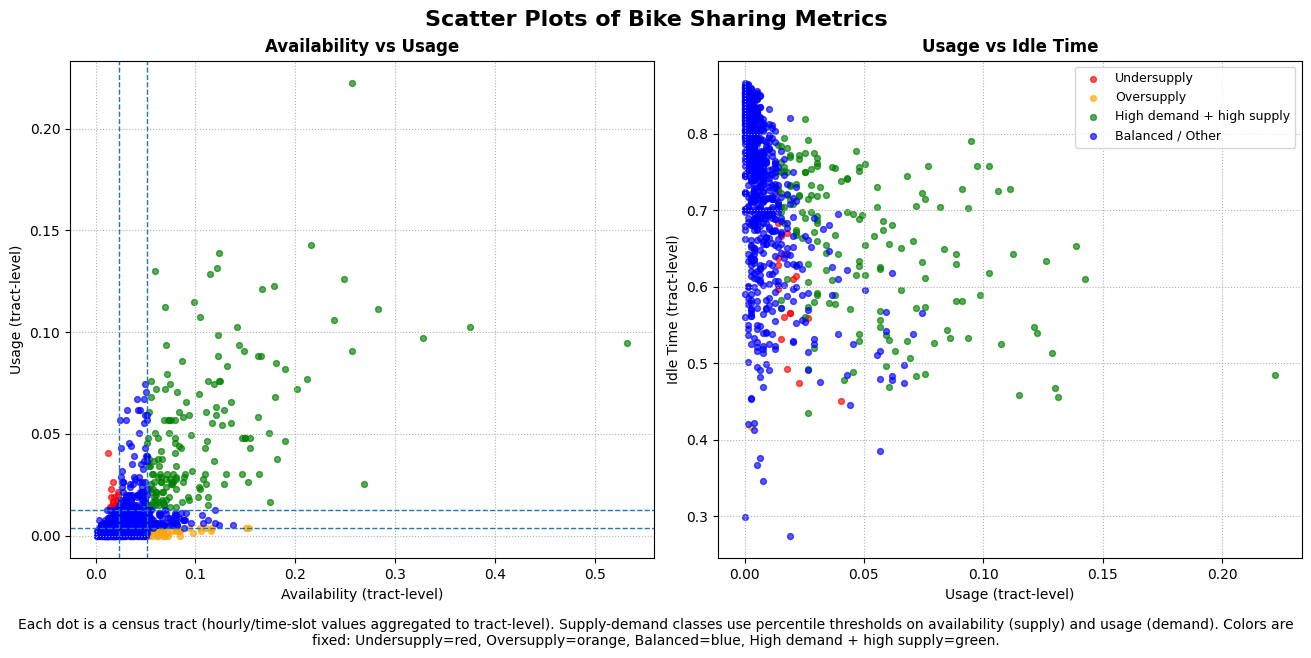

In [2]:
master, class_df, fig = build_scatter_and_supply_demand_classification(
    availability_csv=r"D:\Research Fellowship\NYC_Docked_Output_v2\availability__norm__tract.csv",
    usage_csv=r"D:\Research Fellowship\NYC_Docked_Output_v2\usage_norm_hourly_tract.csv",
    idle_csv=r"D:\Research Fellowship\NYC_Docked_Output_v2\idle_time_norm_tract.csv",
    availability_col="total_vehicle_available_norm",
    usage_col="trips_starting_norm",
    idle_col="avg_idle_time_norm",
    threshold_method="percent",
    use_symmetric_percentiles=True,
    availability_low_pct=30,
    usage_high_pct=70,
    output_dir=r"D:\Research Fellowship\NYC_Docked_Output_v2\UTILITY_INTERACTIONS_OUT",
)

plt.show()